In [2]:
# ================================================================
# 0. Section: IMPORTS
# ================================================================
import numpy as np
from matplotlib import pyplot as plt

from bmiemg.data.maker_archive import BIDSLoader
from bmiemg.plots import plot_emg, add_events
from bmiemg.data.features import get_eeg_channel_names, get_event_labels

from pathlib import Path

import mne

def process_description(
    description: str | int,
    mapping_movement_to_label: dict[int, list[int]],
    special_codes: dict[str, str],
    event_id: dict[str, int],
    phase_code: tuple[int, ...] = (3,),
    arm_code: tuple[int, ...] = (1, 2),
    baseline_code: tuple[int, ...] = (1, 2, 3),
) -> str:
    description_str = str(description) # '9701'
    # print(f"processing description: {description}")
    # [phase, arm, baseline, movement_code]
    # phase: cue (1) prep (2) move (3) return (4) iti (5)
    # arm: left (1) right (2)
    # baseline: up (1) side (2) down (3) (where the arm started from)
    # movement_code
        # 1: openhand_slow_3sec
        # 2: openhand_fast_1sec
        # 3: closetofist_allfingerstogether_slow_3sec
        # 4: closetofist_allfingerstogether_fast_1sec
        # 5: closetofist_allfingerstogether_normalforce_3sec / closetofist_allfingerstogether_3sec_normalforce
        # 6: closetofist_allfingerstogether_3sec_maxforce
        # 7: open_fourfingers_together_3sec
        # 8: close_fourfingers_together_3sec
        # 9: open_onlythumb_3sec
        # 10: close_onlythumb_3sec
        # 11: wrist_palmarflexion_maxforce_3sec
        # 12: wrist_palmarflexion_normalforce_3sec
        # 13: wrist_dorsiflexion_normalforce_3sec
        # 14: wrist_dorsiflexion_maxforce_3sec
        # 15: grasp_cup_3sec
        # 16: grasp_donut_3sec
        # 17: grasping_pinching_pen_allfingers_3sec / grasping_pinching_pen_2fingers_3sec
        # 18: close_pinky_3sec
        # 19: close_ring_3sec
        # 20: close_middle_3sec
        # 21: close_index_3sec
        # 22: close_thumb_3sec
        # 23: open_pinky_3sec
        # 24: open_ring_3sec
        # 25: open_middle_3sec
        # 26: open_index_3sec
        # 27: open_thumb_3sec

    # inverse dict 
    event_id_inverse = {v: k for k, v in event_id.items()}

    if description_str in special_codes:
        # print(f"    Description {description} is a special code corresponding to {special_codes[description]}")
        return special_codes[description_str]
    
    if len(description_str) < 4:
        # print(f"    Description {description} does not have the expected format. Returning 'others'")
        return event_id_inverse[0] 

    # get the movement code from the event label
        # e.g. 12203, 52208, 8899
    # strip [phase, arm, baseline, movement_code] from the event label
    phase, arm, baseline, movement_code = int(description_str[0:1]), int(description_str[1:2]), int(description_str[2:3]), int(description_str[3:])
    
    # print(f"    Parsed description: {description} -> phase: {phase}, arm: {arm}, baseline: {baseline}, movement_code: {movement_code}")
    if ((phase in phase_code) and (arm in arm_code) and (baseline in baseline_code)):
        # print(f"    Checking movement code...")
        for movement, codes in mapping_movement_to_label.items():
            if movement_code in codes:
                return event_id_inverse[movement]
    
    # print(f"    Description {description} does not correspond to any event of interest. Returning 'others'")
    return event_id_inverse[0]

In [3]:
# ================================================================
# 1. Section: INPUTS
# ================================================================
# ROOT: Path = Path(__file__).resolve().parents[1]
ROOT: Path = Path("/Users/charl/Documents/EPFL/NPulse/2025-2026/BMI-SOFT-EMG-Decoding")
DATA: Path = ROOT / "data" / "bids"

#   -> to be checked which ones are best
EEG_CHANNELS = [
    # Premotor / SMA
    "FC1", "FC2", "FC3", "FC4", "FCZ",
    # Sensorimotor strip
    "C1", "C2", "C3", "C4", "CZ",
    # Centro-parietal
    "CP1", "CP2", "CP3", "CP4",
    # Frontal surround
    "F3", "FZ", "F4",
    # Parietal surround
    "P3", "PZ", "P4",
]

# select timepoints of interest
phase_code = (3,) # movement phase
arm_code = (1, 2) # both arms
baseline_code = (1, 2, 3) # all baselines

event_id_truth = {
    "others":0,
    "hand_open":1,
    "hand_close":2,
    "wrist_flexion":3,
    "wrist_extension":4,
    "grasp":5,
    "pinch":6,
    "experiment_end":7,
    "rest_closed":8,
    "rest_open":9,
}

labels_of_interest = {"hand_open", "hand_close", "wrist_flexion", "wrist_extension", "grasp", "pinch"}

special_codes: dict[str, str] = {
    '9701': "rest_open",
    '9702': "rest_closed",
    '8888': "start_LabRecorder",
    '9999': "test_marker",
    '8899': "experiment_end",
}

mapping_movement_to_label = {
    1: [1, 2, 7, 9],  # hand_open (9 ,ight be dropped)
    2: [3, 4, 5, 6, 8, 10],  # hand_close (10 might be dropped)
    3: [11, 12],  # wrist_flexion
    4: [13, 14],  # wrist_extension
    5: [15, 16],  # grasp
    6: [17]   # pinch
}

tmin, tmax = -0.5, 1.5

bad_paths = [
    "/Users/charl/Documents/EPFL/NPulse/2025-2026/BMI-SOFT-EMG-Decoding/data/bids/2025-11-21/sub-05/ses-07/eeg/sub-05_ses-07_task-Side_run-01_eeg.fif",
]

In [4]:
bids = BIDSLoader(
    data_dir=DATA,
    modality="eeg",
    file_type=".fif" # ".fif"
)
paths = bids.bids_paths
full_index = len(paths)

Extracting BIDS paths from date-based folder structure at /Users/charl/Documents/EPFL/NPulse/2025-2026/BMI-SOFT-EMG-Decoding/data/bids...
Extracting BIDS paths from folder: 2025-11-21...
    -> Found 5 BIDS paths in folder: 2025-11-21.
Extracting BIDS paths from folder: 2025-11-27...
    -> Found 4 BIDS paths in folder: 2025-11-27.
Extracting BIDS paths from folder: 2025-11-12...
    -> Found 4 BIDS paths in folder: 2025-11-12.
Total BIDS paths found across all folders: 13.


In [ ]:
X_all = []
y_all = []
for i, path in enumerate(paths):
    if str(path) in bad_paths:
        print(f"Skipping known bad file: {path}")
        continue
    raw = bids.load_dataset(i)
    raw.load_data()
    print(f"{i}/{full_index} - processing file: {path} with shape {raw.get_data().shape} and channels {raw.info['ch_names']}")
    # test_eeg is a raw MNE object

    raw = raw.pick(EEG_CHANNELS)

    # process to extract the epochs and events
    # other preprocessing necessary?
    raw.filter(1., 50., fir_design='firwin', verbose="error") # Band-pass filter 1-50Hz
    raw.notch_filter(freqs=[50, 100], verbose="error")

    # get the annotations
    channels_names = np.asarray(get_eeg_channel_names(raw))
    data = np.asarray(raw.get_data(picks=channels_names))
    times = np.asarray(raw.times)
    visible_annotations = get_event_labels(raw, tmin=times[0], tmax=times[-1]) # lsl_code

    # set the annotations with the processed event labels
    onsets = [ann[0] for ann in visible_annotations]
    durations = [ann[1] for ann in visible_annotations]
    descriptions = [process_description(description=ann[2], 
            phase_code=phase_code, arm_code=arm_code, baseline_code=baseline_code, 
            mapping_movement_to_label=mapping_movement_to_label, special_codes=special_codes, 
            event_id=event_id_truth) 
        for ann in visible_annotations]
    new_annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions)

    assert len(visible_annotations) == len(new_annotations), "The number of visible annotations and new annotations should be the same"

    raw.set_annotations(new_annotations)

    # epoch the data
    events, event_id = mne.events_from_annotations(
        raw, 
        event_id=event_id_truth
    )
    event_id_of_interest = {k: event_id[k] for k in labels_of_interest if k in event_id}

    try:
        epochs = mne.Epochs(
            raw,
            events,
            event_id_of_interest,
            tmin=tmin,
            tmax=tmax,
            proj=True,
            picks=EEG_CHANNELS,
            baseline=None,
            preload=True,
            # reject=dict(grad=4000e-13, eog=150e-6),
            decim=3,
            verbose="error",
        )

        X_file = epochs.get_data(copy=False)  # n_epochs, n_eeg_channels, n_times
        y_file = epochs.events[:, 2]

        print(f"    Extracted epochs with shape {X_file.shape} and labels {np.unique(y_file)}")
        X_all.append((X_file))
        y_all.append((y_file))

        # epochs[np.str_('hand_close')].compute_psd().plot(picks="eeg", exclude="bads", amplitude=False)
        # plt.plot()

    except Exception as e:
        print(f"Error processing file {path}: {e}")

    # del raw, data, times, visible_annotations, new_annotations, epochs
    print("--------------------------------------------------")
    # break

X_all = np.concatenate(X_all, axis=0) # # n_epochs, n_eeg_channels, n_times (219, 20, 1000)
y_all = np.concatenate(y_all, axis=0) # labels: 6 classes
print(f"Final dataset shape: {X_all.shape}, labels shape: {y_all.shape}")
# Final dataset shape: (613, 20, 667), labels shape: (613,)

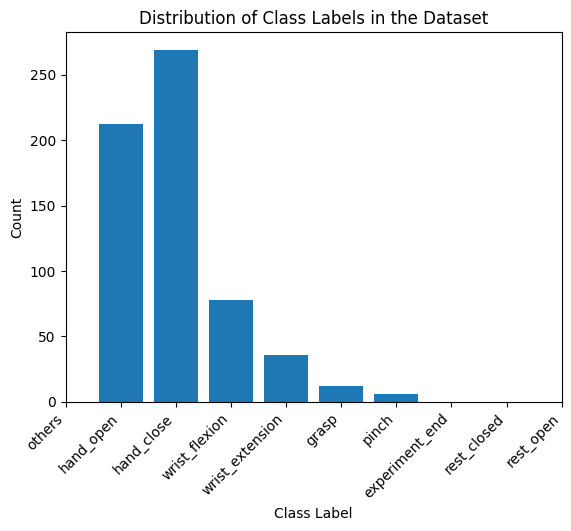

In [6]:
# plot label distribution
import matplotlib.pyplot as plt
unique, counts = np.unique(y_all, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.xticks(list(event_id_truth.values()), list(event_id_truth.keys()),
              rotation=45, ha='right') # set x-ticks to be the unique class labels
plt.title("Distribution of Class Labels in the Dataset")
plt.show()

## Decoding

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.multiclass import OneVsRestClassifier
from mne.decoding import SlidingEstimator, Vectorizer, cross_val_multiscore
from sklearn.model_selection import StratifiedKFold

### Decoding 1: sliding estimator - all timesteps as input 
Input features: pure epochs
Epochs: [-0.5, 1.5]

#### 1.0 Random: 16%

In [ ]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        DummyClassifier(strategy='uniform', random_state=42)
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_all, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

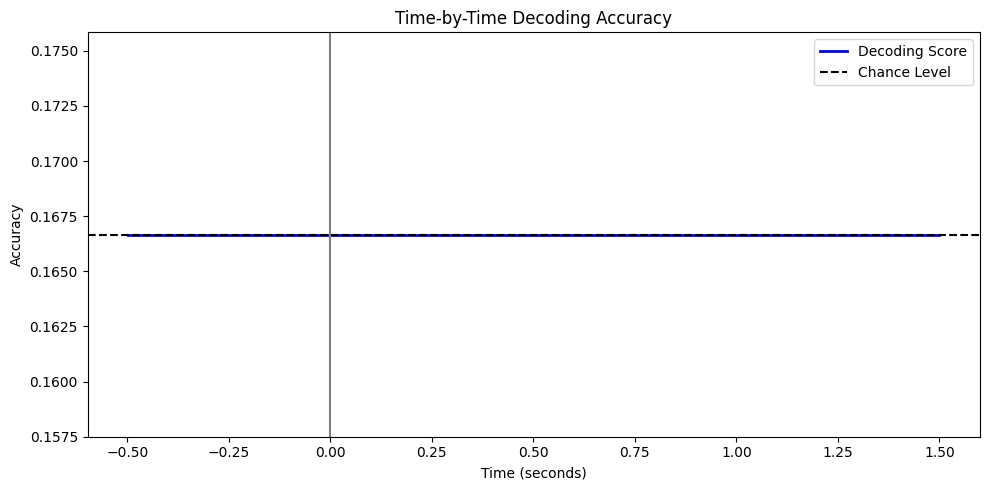

In [58]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(epochs.times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 1.1 Logistic Regression: bad%

In [ ]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        LogisticRegression(max_iter=1000, solver='liblinear')
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_all, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

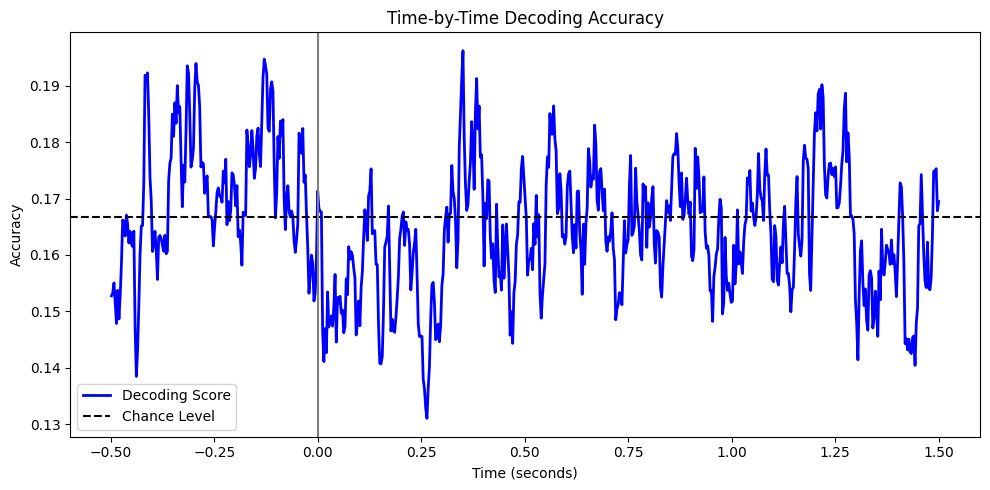

In [10]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(epochs.times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 1.2: Decision Tree: random
Input features: pure epochs
Epochs: [-0.5, 1.5]

In [ ]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        DecisionTreeRegressor()
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_all, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

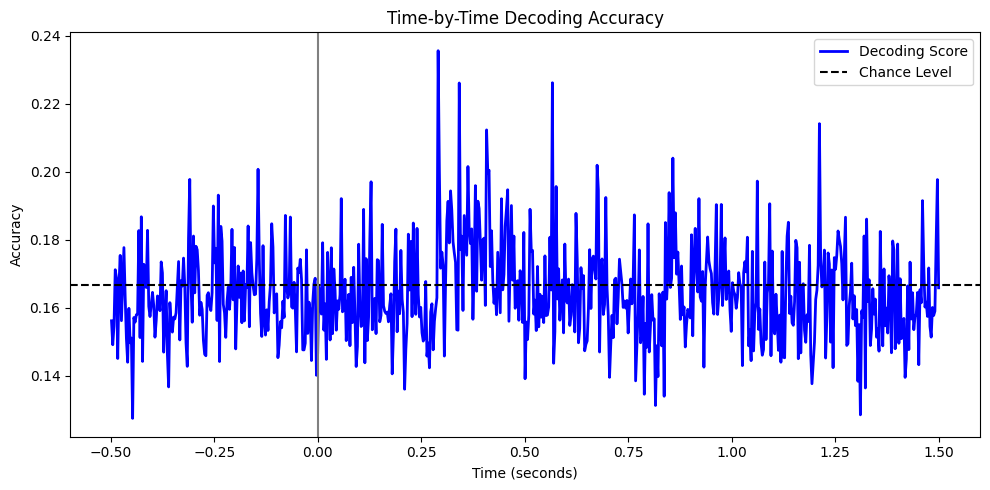

In [15]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(epochs.times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 1.3. SVM/SVC
Input features: pure epochs
Epochs: [-0.5, 1.5]

In [ ]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        svm.SVC()
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_all, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

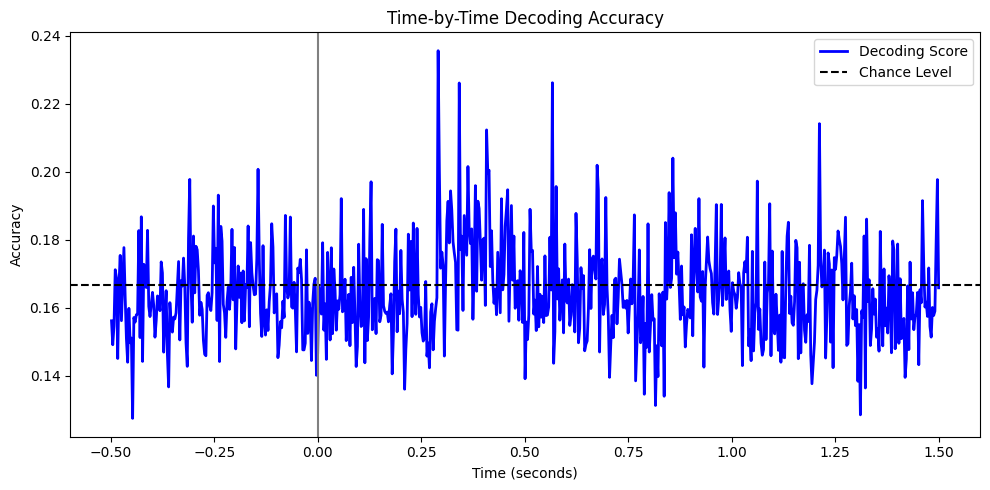

In [ ]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(epochs.times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

### Decoding 4. Vectorization - all timesteps as input 

#### 4.1 Random baseline accuracy: 12.90%

In [30]:
from sklearn.dummy import DummyClassifier

# 1. Build the baseline pipeline
baseline_clf = make_pipeline(
    Vectorizer(),                     
    StandardScaler(),                 
    # We replace the entire SVM/OneVsRest setup with the DummyClassifier
    DummyClassifier(strategy='uniform', random_state=42) 
)

# 2. Evaluate using the exact same cross-validation and scoring
baseline_scores = cross_val_multiscore(
    baseline_clf, 
    X_all, 
    y_all, 
    cv=cv, 
    scoring='balanced_accuracy', 
    n_jobs=-1
)

print(f"Random Baseline Accuracy: {baseline_scores.mean() * 100:.2f}%")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.8s remaining:    1.2s


Random Baseline Accuracy: 15.90%


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.5s finished


#### 4.2 Logistic regression: 29.78%

In [19]:
# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    Vectorizer(),                     # Flattens (epochs, channels, times) -> (epochs, features)
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        LogisticRegression(max_iter=1000, solver='liblinear') 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_all, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:  1.3min remaining:  2.0min


Mean decoding accuracy: 29.78%


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  1.4min finished


#### 4.3 Decision Tree Regressor: 22.43%

In [20]:
# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    Vectorizer(),                     # Flattens (epochs, channels, times) -> (epochs, features)
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        DecisionTreeRegressor() 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_all, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   40.9s remaining:  1.0min


Mean decoding accuracy: 22.43%


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   45.8s finished


#### 4.4 SVC: 23.51%

In [21]:
from sklearn import svm

# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    Vectorizer(),                     # Flattens (epochs, channels, times) -> (epochs, features)
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        svm.SVC() 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_all, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   25.7s remaining:   38.6s


Mean decoding accuracy: 23.51%


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   33.9s finished


### Decoding 5. Band power calculation (vectorization)

In [63]:
from scipy.signal import welch

# Define standard EEG frequency bands (Hz)
EEG_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta':  (12, 30),
    'Gamma': (30, 45) # Keep below 50Hz to avoid powerline noise
}

sfreq = epochs.info['sfreq']

def extract_band_power(X, fs):
    """
    X: NumPy array of shape (n_epochs, n_channels, n_times)
    fs: Sampling frequency in Hz
    """
    n_epochs, n_channels, n_times = X.shape
    n_bands = len(EEG_BANDS)
    
    # Pre-allocate feature matrix: shape (n_epochs, n_channels * n_bands)
    features = np.zeros((n_epochs, n_channels * n_bands))
    
    # 1. Calculate PSD using Welch's method
    # nperseg defines frequency resolution. If fs=250, nperseg=250 gives 1Hz resolution.
    freqs, psd = welch(
        X, 
        fs=fs, 
        window='hann', 
        nperseg=fs,        # 1-second segments
        noverlap=fs // 2,  # 50% overlap
        axis=-1            # Compute over the time dimension
    )
    
    # 2. Extract power for each band
    for band_idx, (band_name, (fmin, fmax)) in enumerate(EEG_BANDS.items()):
        # Find the array indices that match our frequency range
        freq_mask = np.logical_and(freqs >= fmin, freqs <= fmax)
        
        # Sum the PSD values within this band across the last axis (frequencies)
        # Using Simpson's rule or np.trapz is technically more accurate, 
        # but a simple sum is computationally cheaper for C and usually works just as well.
        band_power = np.sum(psd[:, :, freq_mask], axis=-1)
        
        # Flatten the channels into the 2D feature matrix
        start_col = band_idx * n_channels
        end_col = (band_idx + 1) * n_channels
        features[:, start_col:end_col] = band_power
        
    return features

In [64]:
X_band_power = extract_band_power(X_all, sfreq)
print(f"Extracted band power features with shape: {X_band_power.shape}")

Extracted band power features with shape: (613, 100)


#### 5.1 Random baseline accuracy: 15.90%

In [ ]:
from sklearn.dummy import DummyClassifier

# 1. Build the baseline pipeline
baseline_clf = make_pipeline(
    Vectorizer(),                     
    StandardScaler(),                 
    # We replace the entire SVM/OneVsRest setup with the DummyClassifier
    DummyClassifier(strategy='uniform', random_state=42) 
)

# 2. Evaluate using the exact same cross-validation and scoring
baseline_scores = cross_val_multiscore(
    baseline_clf, 
    X_band_power, 
    y_all, 
    cv=cv, 
    scoring='balanced_accuracy', 
    n_jobs=-1
)

print(f"Random Baseline Accuracy: {baseline_scores.mean() * 100:.2f}%")

#### 5.2 Logistic regression: 30.57%

In [ ]:
X_band_power

In [ ]:
# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        LogisticRegression() 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_band_power, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Mean decoding accuracy: 30.57%


[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    3.2s remaining:    4.8s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.2s finished


In [66]:
# download the clf and scaler for later use
import joblib
# Fit the pipeline on the entire dataset
clf.fit(X_band_power, y_all)
joblib.dump(clf, 'clf.pkl')

['clf.pkl']

#### 5.3 Decision tree regression: 29.85%

In [27]:
# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    Vectorizer(),                     # Flattens (epochs, channels, times) -> (epochs, features)
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        DecisionTreeRegressor() 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_band_power, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.3s remaining:    0.5s


Mean decoding accuracy: 29.85%


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    3.3s finished


#### 5.4 SVM/SVC: 31.36%

In [ ]:
# 1. Build the MNE / Scikit-Learn pipeline
clf = make_pipeline(
    Vectorizer(),                     # Flattens (epochs, channels, times) -> (epochs, features)
    StandardScaler(),                 # Standardizes the features
    OneVsRestClassifier(              # Applies the One-vs-Rest multiclass scheme
        svm.SVC() 
    )
)

# 2. Set up cross-validation (Stratified keeps class ratios balanced)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Evaluate the model using MNE's cross_val_multiscore
# 'balanced_accuracy'? 
scores = cross_val_multiscore(clf, X_band_power, y_all, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
print(f"Mean decoding accuracy: {scores.mean() * 100:.2f}%")


Mean decoding accuracy: 31.36%


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:    0.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished


### Decoding 6. Band power calculation & timesteps

#### calculation

In [32]:
import numpy as np
from scipy.signal import welch

# Define standard EEG frequency bands (Hz)
EEG_BANDS = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta':  (12, 30),
    'Gamma': (30, 45) # Keep below 50Hz to avoid powerline noise
}

def extract_band_power_intervals(X, fs, n_intervals=4):
    """
    X: NumPy array of shape (n_epochs, n_channels, n_times)
    fs: Sampling frequency in Hz
    n_intervals: Number of time chunks to divide each epoch into
    """
    n_epochs, n_channels, n_times = X.shape
    n_bands = len(EEG_BANDS)
    
    # 1. Calculate how many samples fit into each interval
    samples_per_interval = n_times // n_intervals
    
    # 2. Prevent Welch window from being larger than the data chunk.
    # If the interval is smaller than 1 second, reduce the window size.
    nperseg = min(fs, samples_per_interval)
    
    # 3. Pre-allocate 3D feature matrix: (epochs, features, intervals)
    features = np.zeros((n_epochs, n_channels * n_bands, n_intervals))
    
    for i in range(n_intervals):
        # Slice the raw data for the current time chunk
        start_idx = i * samples_per_interval
        end_idx = start_idx + samples_per_interval
        X_chunk = X[:, :, start_idx:end_idx]
        
        # Calculate PSD on this specific time chunk
        freqs, psd = welch(
            X_chunk, 
            fs=fs, 
            window='hann', 
            nperseg=nperseg,       
            noverlap=nperseg // 2, 
            axis=-1            
        )
        
        # Extract power for each band
        for band_idx, (band_name, (fmin, fmax)) in enumerate(EEG_BANDS.items()):
            freq_mask = np.logical_and(freqs >= fmin, freqs <= fmax)
            band_power = np.sum(psd[:, :, freq_mask], axis=-1)
            
            # Map the flattened channels into the 3D array
            start_col = band_idx * n_channels
            end_col = (band_idx + 1) * n_channels
            features[:, start_col:end_col, i] = band_power
            
    return features

# Example execution:
X_band_power = extract_band_power_intervals(X_all, sfreq, n_intervals=4)
print(f"Extracted band power features with shape: {X_band_power.shape}")

Extracted band power features with shape: (613, 100, 4)


#### 6.1 Logistic regression: 26%

In [33]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        LogisticRegression(max_iter=1000, solver='liblinear')
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_band_power, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]
  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]

  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]



  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]


100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    5.20it/s][A




 50%|█████     | Fitting SlidingEstimator : 2/4 [00:00<00:00,    6.27it/s]

 50%|█████     | Fitting SlidingEstimator : 2/4 [00:00<00:00,    5.68it/s]


 25%|██▌       | Fitting SlidingEstimator : 1/4 [00:00<00:00,    3.88it/s]
 50%|█████     | Fitting SlidingEstimator : 2/4 [00:00<00:00,    5.12it/s]

100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,   10.87it/s]



100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,   10.62it/s]
100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,   10.97it/s]



100%|██████████| F

In [49]:
alpha = (tmax - tmin)/X_band_power.shape[-1]/2
time = np.arange(tmin+alpha, tmax+alpha, alpha*2)

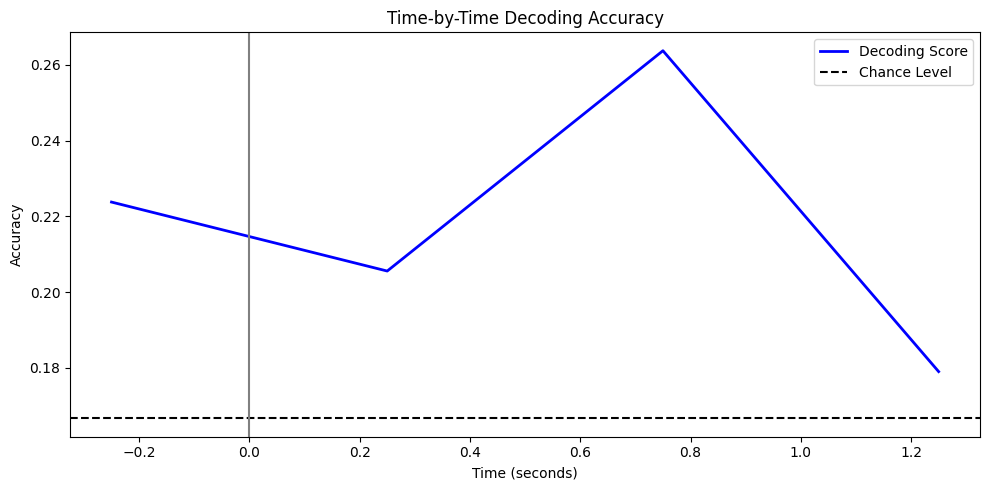

In [50]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(time, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.2 Decision tree: 20.5%

In [51]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        DecisionTreeRegressor()
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_band_power, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.

  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]

  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]


  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]



  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]


 25%|██▌       | Fitting SlidingEstimator : 1/4 [00:00<00:01,    2.86it/s]
 75%|███████▌  | Fitting SlidingEstimator : 3/4 [00:00<00:00,    6.77it/s]

 50%|█████     | Fitting SlidingEstimator : 2/4 [00:00<00:00,    4.52it/s]
100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    8.46it/s]


100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    8.62it/s]



 75%|███████▌  | Fitting SlidingEstimator : 3/4 [00:00<00:00,    7.29it/s]



100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    9.20it/s]
100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,   16.81it/s]
[Parallel(n_jobs=-1)]:

In [52]:
alpha = (tmax - tmin)/X_band_power.shape[-1]/2
time = np.arange(tmin+alpha, tmax+alpha, alpha*2)

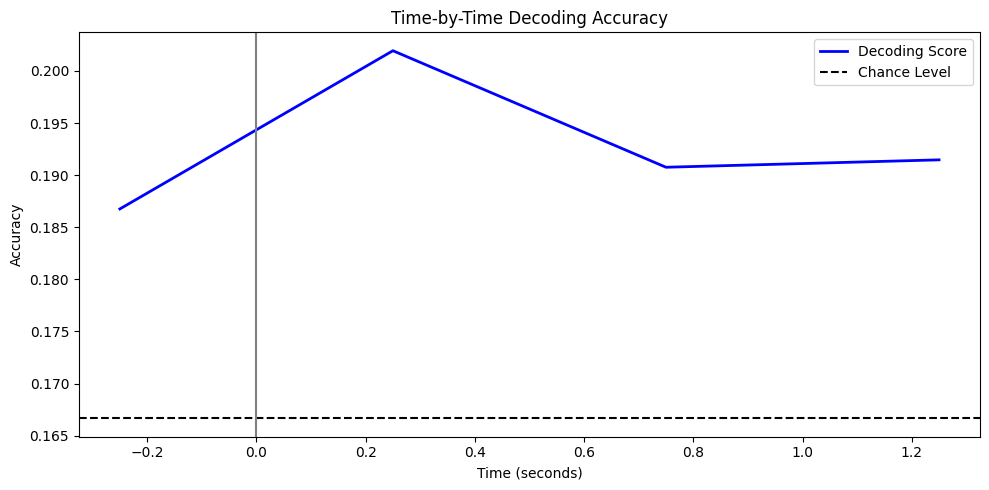

In [53]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(time, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### 6.3 SVM: 21%

In [54]:
# 1. Build the base pipeline (No Vectorizer needed here!)
base_clf = make_pipeline(
    StandardScaler(),                 # Standardizes the channels at each time point
    OneVsRestClassifier(
        svm.SVC()
    )
)

# 2. Wrap the pipeline in MNE's SlidingEstimator
time_decode = SlidingEstimator(
    base_clf, 
    n_jobs=-1, 
    scoring='balanced_accuracy', # Or 'roc_auc_ovr' for multiclass ROC AUC
    verbose=True
)

# 3. Evaluate across time
# The output `scores` will be an array of shape (n_splits, n_times)
scores = cross_val_multiscore(time_decode, X_band_power, y_all, cv=5, n_jobs=-1)

# You can average across splits to get the score at each time point
mean_scores_over_time = scores.mean(axis=0)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]
  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]

  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]


  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]



  0%|          | Fitting SlidingEstimator : 0/4 [00:00<?,       ?it/s]
100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    8.06it/s]


 25%|██▌       | Fitting SlidingEstimator : 1/4 [00:00<00:01,    2.62it/s]
 50%|█████     | Fitting SlidingEstimator : 2/4 [00:00<00:00,    5.17it/s]


 25%|██▌       | Fitting SlidingEstimator : 1/4 [00:00<00:00,    4.89it/s]
100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,    9.36it/s]


 75%|███████▌  | Fitting SlidingEstimator : 3/4 [00:00<00:00,    7.16it/s]


100%|██████████| Fitting SlidingEstimator : 4/4 [00:00<00:00,   15.01it/s]




 25%|██▌       | Fitting SlidingEstimator : 1/4 [00:00<00:00,    5.05it/s]

100%|██████████| Fitting S

In [55]:
alpha = (tmax - tmin)/X_band_power.shape[-1]/2
time = np.arange(tmin+alpha, tmax+alpha, alpha*2)

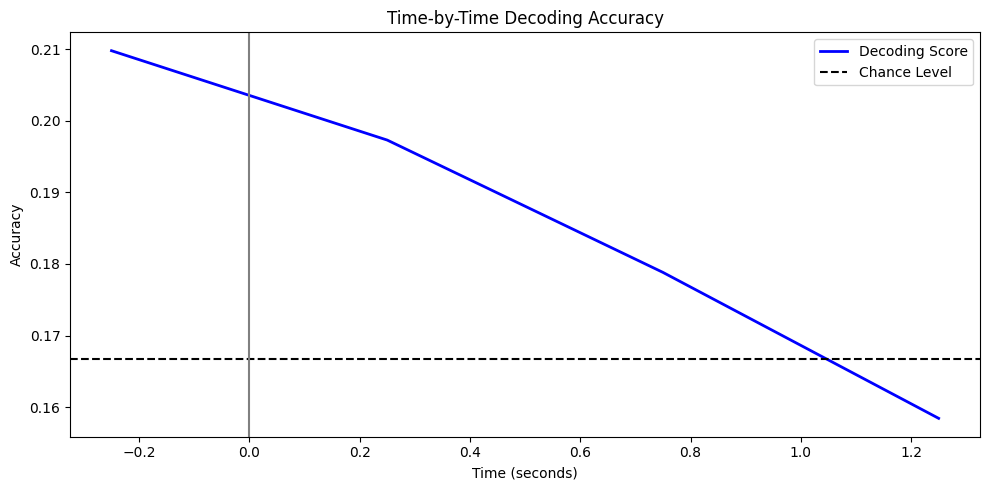

In [56]:
# 1. Define your chance level (e.g., 0.5 for 2 classes, 0.33 for 3 classes)
# Update 'n_classes' to match your actual number of categories
n_classes = len(np.unique(y_all)) 
chance_level = 1.0 / n_classes

# 2. Plot the time-by-time decoding accuracy
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the mean scores (multiply by 100 if you want percentages)
ax.plot(time, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)
# ax.plot(times, mean_scores_over_time, label='Decoding Score', color='b', linewidth=2)


# Add a horizontal line for random chance
ax.axhline(chance_level, color='k', linestyle='--', label='Chance Level')

# Add a vertical line for the stimulus onset (time = 0)
ax.axvline(0, color='gray', linestyle='-')

# Formatting
ax.set_title('Time-by-Time Decoding Accuracy')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()